# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Linda Putriani
- **Email:** lindaptrn@gmail.com
- **ID Dicoding:** linda_ptrn

## Menentukan Pertanyaan Bisnis

1. Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?
2. Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

### 1. Mengumpulkan Data Harian (day.csv)

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

Dataset day.csv berhasil dimuat. Dataset ini berisi data agregat penyewaan sepeda per hari, termasuk informasi musim, cuaca, suhu, dan total penyewaan (cnt).

### 2. Mengumpulkan Data Per Jam (hour.csv)

In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Dataset hour.csv berhasil dimuat. Dataset ini berisi data penyewaan sepeda per jam yang memungkinkan analisis pola waktu secara lebih detail.

### Assessing Data

### **1. Assessing day_df**

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

Berdasarkan hasil pemeriksaan menggunakan info(), dapat diketahui bahwa dataset day_df memiliki jumlah baris yang konsisten dan seluruh kolom memiliki tipe data yang sesuai dengan karakteristiknya. Sebagian besar variabel bertipe numerik (integer dan float), yang sesuai karena dataset ini berisi data kuantitatif seperti suhu, kelembapan, serta jumlah penyewaan. Kolom dteday masih bertipe object sebelum dilakukan konversi, yang menunjukkan bahwa data tanggal masih berupa string.

Hasil pengecekan missing value menggunakan isnull().sum() menunjukkan bahwa tidak terdapat nilai kosong pada seluruh kolom. Hal ini menandakan kualitas data cukup baik dan tidak memerlukan proses imputasi atau penghapusan baris.

Selain itu, hasil pengecekan duplikasi menggunakan duplicated().sum() menunjukkan bahwa tidak terdapat data yang terduplikasi. Artinya, setiap baris data merepresentasikan observasi yang unik. Secara keseluruhan, dataset harian ini memiliki kualitas data yang baik dan siap untuk dianalisis lebih lanjut.

### 2. Assessing hour_df

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

Dataset hour_df memiliki struktur yang serupa dengan day_df, namun dengan tambahan kolom hr yang menunjukkan jam ke berapa penyewaan terjadi. Berdasarkan hasil info(), dataset ini memiliki jumlah baris yang jauh lebih banyak dibandingkan dataset harian karena mencatat data setiap jam. Tipe data pada setiap kolom juga sesuai, di mana variabel numerik digunakan untuk merepresentasikan pengukuran kuantitatif seperti suhu dan jumlah penyewaan.

Hasil pengecekan missing value menunjukkan bahwa tidak terdapat nilai kosong dalam dataset ini. Hal ini sangat penting karena data per jam memiliki volume yang besar, dan keberadaan missing value dapat mempengaruhi analisis pola waktu.

Pemeriksaan duplikasi juga menunjukkan bahwa tidak terdapat baris data yang identik. Dengan demikian, dapat disimpulkan bahwa dataset per jam memiliki kualitas data yang baik dan konsisten sehingga dapat digunakan untuk analisis lebih lanjut tanpa perlu pembersihan data yang signifikan.

### Cleaning Data

Cleaning Dataset Harian (day_df)

Menghapus Duplikasi

In [12]:
# Menghapus duplikasi pada day_df
day_df.drop_duplicates(inplace=True)

print("Jumlah duplikasi setelah cleaning (day_df):", day_df.duplicated().sum())

Jumlah duplikasi setelah cleaning (day_df): 0


**Insight:**

Berdasarkan hasil pemeriksaan sebelumnya, dataset harian tidak memiliki data duplikat. Namun proses drop_duplicates() tetap dilakukan sebagai langkah preventif untuk memastikan tidak ada baris identik yang dapat mempengaruhi hasil analisis. Setelah dilakukan validasi ulang, jumlah duplikasi tetap nol sehingga dataset dinyatakan bersih dari data ganda.

Mengubah Tipe Data Kolom Tanggal

In [13]:
# Mengubah tipe data kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

Insight:

Kolom dteday awalnya bertipe object (string). Konversi ke tipe datetime sangat penting untuk analisis berbasis waktu seperti tren bulanan, tahunan, maupun analisis musiman. Dengan tipe datetime, dataset menjadi lebih fleksibel untuk manipulasi waktu seperti ekstraksi bulan, tahun, atau hari.

Mapping Variabel Kategori

In [14]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow"
}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Insight:

Variabel season dan weathersit awalnya direpresentasikan dalam bentuk angka 1–4. Representasi numerik ini kurang informatif saat dilakukan visualisasi atau interpretasi. Oleh karena itu, dilakukan mapping ke label yang lebih deskriptif seperti Spring, Summer, dan Clear. Transformasi ini meningkatkan keterbacaan data tanpa mengubah makna aslinya.

Validasi Akhir day_df

In [15]:
print("Missing value day_df:")
print(day_df.isnull().sum())

print("Jumlah duplikasi day_df:", day_df.duplicated().sum())

Missing value day_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah duplikasi day_df: 0


Insight:

Setelah proses cleaning selesai, tidak ditemukan missing value maupun duplikasi. Dataset harian kini berada dalam kondisi optimal untuk tahap eksplorasi dan visualisasi.

Cleaning Dataset Per Jam (hour_df)

Menghapus Duplikasi

In [16]:
# Menghapus duplikasi pada hour_df
hour_df.drop_duplicates(inplace=True)

print("Jumlah duplikasi setelah cleaning (hour_df):", hour_df.duplicated().sum())

Jumlah duplikasi setelah cleaning (hour_df): 0


Insight:

Dataset per jam memiliki jumlah observasi yang jauh lebih banyak dibandingkan dataset harian. Oleh karena itu, pengecekan dan penghapusan duplikasi menjadi penting untuk memastikan tidak ada data jam yang tercatat lebih dari satu kali. Setelah proses dilakukan, tidak ditemukan duplikasi sehingga dataset dinyatakan konsisten.

Mengubah Tipe Data Kolom Tanggal

In [17]:
# Mengubah tipe data kolom dteday menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

Insight:

Sama seperti dataset harian, kolom tanggal pada dataset per jam diubah menjadi tipe datetime. Transformasi ini memungkinkan analisis lanjutan seperti tren per hari, per bulan, atau analisis pola waktu berdasarkan jam operasional.

Mapping Variabel Kategori

In [18]:
hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,0,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,0,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,0,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,0,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


Insight:

Mapping kategori dilakukan agar hasil visualisasi lebih informatif dan mudah dipahami. Karena dataset per jam sering digunakan untuk analisis pola waktu detail, penggunaan label kategori yang jelas sangat membantu dalam interpretasi grafik.

Validasi Akhir hour_df

In [19]:
print("Missing value hour_df:")
print(hour_df.isnull().sum())

print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

Missing value hour_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah duplikasi hour_df: 0


Insight:

Setelah seluruh proses cleaning selesai, dataset per jam tetap tidak memiliki missing value maupun duplikasi. Hal ini menunjukkan bahwa data memiliki kualitas yang baik dan siap digunakan untuk analisis lebih lanjut.

### ***Setelah proses data wrangling selesai dan dataset dinyatakan bersih, tahap selanjutnya adalah melakukan Exploratory Data Analysis (EDA) untuk menjawab pertanyaan bisnis yang telah dirumuskan sebelumnya.***

## Exploratory Data Analysis (EDA)

### Explore

Rata-rata Penyewaan Berdasarkan Musim (day_df)

In [20]:
day_df.groupby("season")["cnt"].mean().sort_values(ascending=False)

,cnt
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


**Insight:**

Berdasarkan hasil perhitungan rata-rata jumlah penyewaan sepeda berdasarkan musim, terlihat adanya perbedaan yang cukup signifikan antar musim. Musim Summer dan Fall menunjukkan rata-rata penyewaan yang lebih tinggi dibandingkan Spring dan Winter. Hal ini mengindikasikan bahwa kondisi lingkungan dan suhu yang lebih nyaman pada musim tertentu mendorong peningkatan aktivitas bersepeda. Sebaliknya, musim dengan suhu ekstrem cenderung menurunkan minat masyarakat untuk menggunakan layanan penyewaan sepeda.

Rata-rata Penyewaan Berdasarkan Cuaca (day_df)

In [21]:
day_df.groupby("weathersit")["cnt"].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,4876.786177
Mist,4035.862348
Light Snow/Rain,1803.285714


Insight:

Hasil eksplorasi berdasarkan kondisi cuaca menunjukkan bahwa cuaca cerah (Clear) memiliki rata-rata jumlah penyewaan tertinggi. Ketika kondisi cuaca memburuk seperti hujan ringan, kabut, atau salju, terjadi penurunan jumlah penyewaan. Hal ini menunjukkan bahwa faktor cuaca memiliki pengaruh langsung terhadap perilaku pengguna. Pengguna cenderung memilih bersepeda saat kondisi cuaca mendukung aktivitas luar ruangan.

Statistik Deskriptif Jumlah Penyewaan (day_df)

In [22]:
day_df["cnt"].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


Insight:

Statistik deskriptif pada variabel cnt menunjukkan variasi jumlah penyewaan yang cukup besar antara nilai minimum dan maksimum. Hal ini mengindikasikan bahwa permintaan sepeda tidak konstan setiap hari, melainkan dipengaruhi oleh faktor eksternal seperti musim, cuaca, dan kemungkinan hari kerja atau hari libur. Standar deviasi yang cukup tinggi menunjukkan adanya fluktuasi permintaan yang signifikan.

Rata-rata Penyewaan per Jam (hour_df)

In [23]:
hour_df.groupby("hr")["cnt"].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


Insight:

Analisis rata-rata penyewaan berdasarkan jam menunjukkan adanya variasi yang jelas sepanjang hari. Beberapa jam tertentu memiliki tingkat penyewaan yang jauh lebih tinggi dibandingkan jam lainnya. Pola ini mengindikasikan adanya jam-jam sibuk (peak hours) yang kemungkinan berkaitan dengan aktivitas komuter seperti perjalanan kerja atau sekolah.

Heatmap

Setelah melakukan eksplorasi awal terhadap distribusi dan pola rata-rata penyewaan sepeda berdasarkan musim, cuaca, dan jam operasional, langkah selanjutnya adalah menganalisis hubungan antar variabel secara lebih mendalam. Analisis korelasi dilakukan untuk mengidentifikasi variabel numerik yang memiliki hubungan kuat terhadap jumlah penyewaan (cnt). Dengan memahami kekuatan dan arah hubungan antar variabel, kita dapat memperoleh gambaran yang lebih komprehensif mengenai faktor-faktor yang berkontribusi terhadap fluktuasi permintaan layanan penyewaan sepeda.

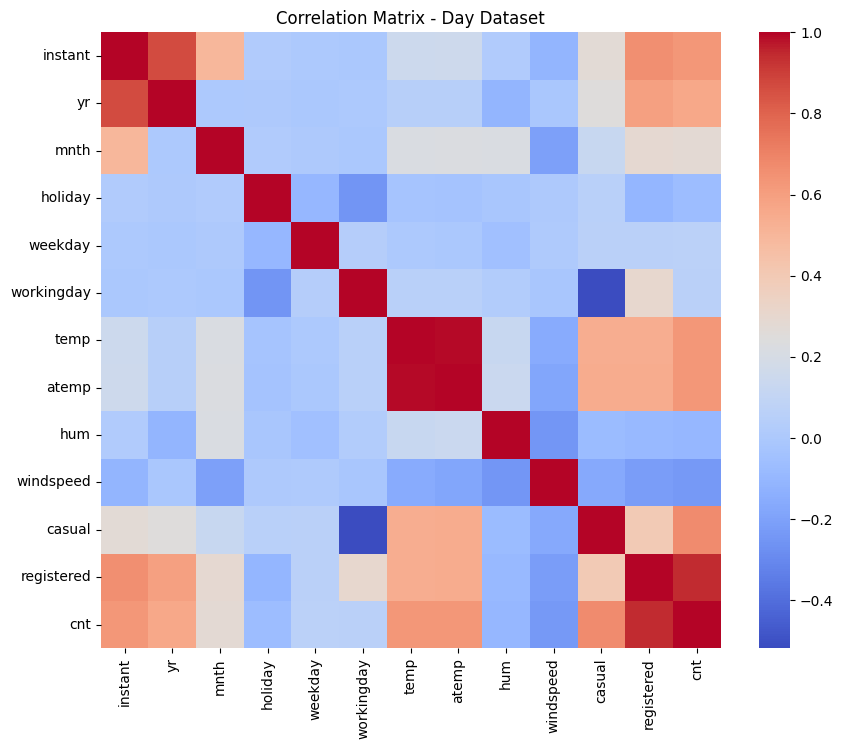

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(day_df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix - Day Dataset")
plt.show()

Insight:

Berdasarkan correlation matrix, terlihat bahwa variabel temp dan atemp memiliki korelasi positif yang cukup kuat terhadap variabel cnt. Hal ini menunjukkan bahwa peningkatan suhu berkaitan dengan peningkatan jumlah penyewaan sepeda. Sebaliknya, variabel seperti hum (kelembapan) menunjukkan kecenderungan korelasi negatif terhadap cnt, yang mengindikasikan bahwa tingkat kelembapan yang tinggi dapat menurunkan minat pengguna untuk bersepeda. Temuan ini memperkuat hasil analisis sebelumnya bahwa faktor kondisi lingkungan memiliki peran penting dalam memengaruhi perilaku pengguna.

***Berdasarkan hasil analisis korelasi sebelumnya, diketahui bahwa beberapa variabel lingkungan memiliki hubungan yang cukup kuat terhadap jumlah penyewaan sepeda. Namun, untuk memperoleh pemahaman yang lebih mendalam mengenai pola permintaan, diperlukan pendekatan segmentasi yang mampu mengelompokkan hari operasional berdasarkan tingkat intensitas penyewaan. Oleh karena itu, dilakukan analisis lanjutan menggunakan teknik clustering sederhana berbasis binning untuk mengklasifikasikan tingkat permintaan menjadi beberapa kategori yang lebih terstruktur.***

Analisis Lanjutan – Clustering Berdasarkan Intensitas Permintaan

Membuat Kategori Permintaan

In [25]:
# Clustering menggunakan teknik binning (quantile-based)
day_df['demand_category'] = pd.qcut(
    day_df['cnt'],
    q=3,
    labels=['Low Demand', 'Medium Demand', 'High Demand']
)

day_df[['cnt', 'demand_category']].head()

,cnt,demand_category
0,985,Low Demand
1,801,Low Demand
2,1349,Low Demand
3,1562,Low Demand
4,1600,Low Demand


Distribusi Kategori

In [26]:
day_df['demand_category'].value_counts()

,count
demand_category,
Low Demand,244
Medium Demand,244
High Demand,243


Visualisasi Clustering

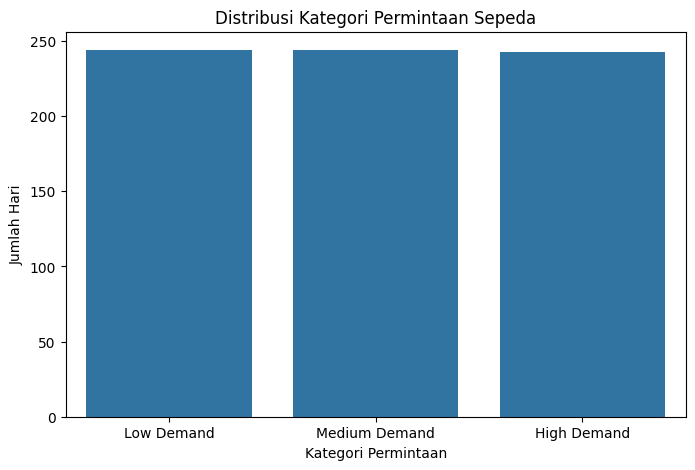

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=day_df, x='demand_category',
              order=['Low Demand','Medium Demand','High Demand'])
plt.title("Distribusi Kategori Permintaan Sepeda")
plt.xlabel("Kategori Permintaan")
plt.ylabel("Jumlah Hari")
plt.show()

Insight:

Berdasarkan hasil clustering menggunakan teknik binning berbasis quantile, hari operasional dapat diklasifikasikan menjadi tiga kategori utama yaitu Low Demand, Medium Demand, dan High Demand. Pendekatan ini memungkinkan identifikasi pola permintaan secara lebih terstruktur dibandingkan hanya melihat nilai rata-rata. Kategori High Demand merepresentasikan periode dengan aktivitas penyewaan tertinggi, yang cenderung terjadi pada musim dengan suhu optimal dan kondisi cuaca cerah. Segmentasi ini memberikan nilai tambah dalam perencanaan kapasitas operasional dan distribusi sepeda secara lebih efisien.

In [28]:
pd.crosstab(day_df['season'], day_df['demand_category'])

demand_category,Low Demand,Medium Demand,High Demand
season,,,
Fall,13,79,96
Spring,140,33,8
Summer,37,71,76
Winter,54,61,63


Insight:

Hasil tabulasi silang menunjukkan bahwa kategori High Demand lebih dominan pada musim Summer dan Fall, yang memperkuat hasil analisis sebelumnya mengenai pengaruh faktor musiman terhadap intensitas penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?

Hitung Rata-rata

In [29]:
season_avg = day_df.groupby("season")["cnt"].mean()
season_avg

,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


Visualisasi Musim

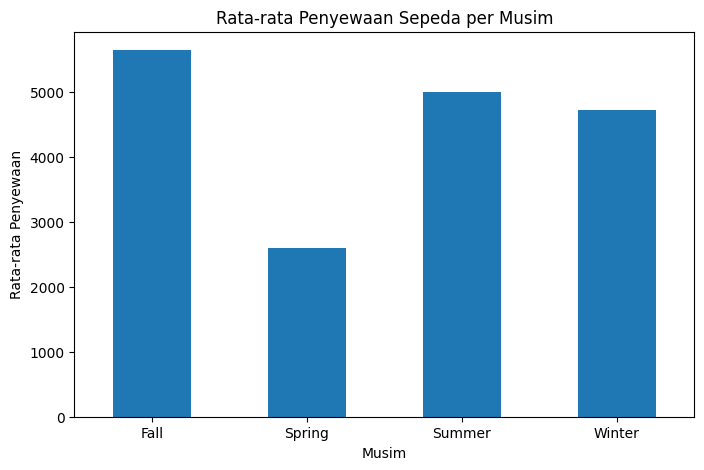

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
season_avg.plot(kind="bar")
plt.title("Rata-rata Penyewaan Sepeda per Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(rotation=0)
plt.show()

Insight:

Visualisasi rata-rata penyewaan sepeda per musim memperjelas bahwa musim Summer dan Fall memiliki tingkat penyewaan tertinggi. Kondisi cuaca yang lebih stabil dan suhu yang nyaman pada musim tersebut mendorong aktivitas bersepeda. Sebaliknya, musim Winter menunjukkan rata-rata penyewaan terendah, yang kemungkinan disebabkan oleh suhu rendah serta kondisi lingkungan yang kurang mendukung. Dengan demikian, musim merupakan faktor penting yang memengaruhi permintaan layanan penyewaan sepeda.

### Pertanyaan 2: Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?

Hitung Rata-rata

In [31]:
weather_avg = day_df.groupby("weathersit")["cnt"].mean()
weather_avg

,cnt
weathersit,
Clear,4876.786177
Light Snow/Rain,1803.285714
Mist,4035.862348


Visualisasi Cuaca

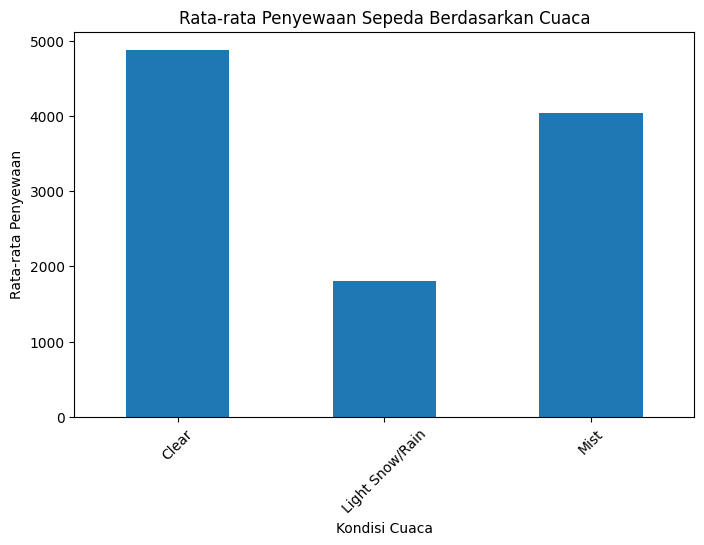

In [32]:
plt.figure(figsize=(8,5))
weather_avg.plot(kind="bar")
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Grafik rata-rata penyewaan berdasarkan kondisi cuaca menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda. Cuaca cerah menghasilkan tingkat penyewaan tertinggi, sementara hujan atau salju berat menyebabkan penurunan signifikan. Hal ini menunjukkan bahwa cuaca memiliki dampak yang cukup kuat terhadap keputusan pengguna dalam menggunakan sepeda sebagai sarana transportasi.

## Analisis Lanjutan (Opsional)

Hitung Rata-rata per Jam

In [33]:
hour_avg = hour_df.groupby("hr")["cnt"].mean()
hour_avg

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


Visualisasi Pola Jam

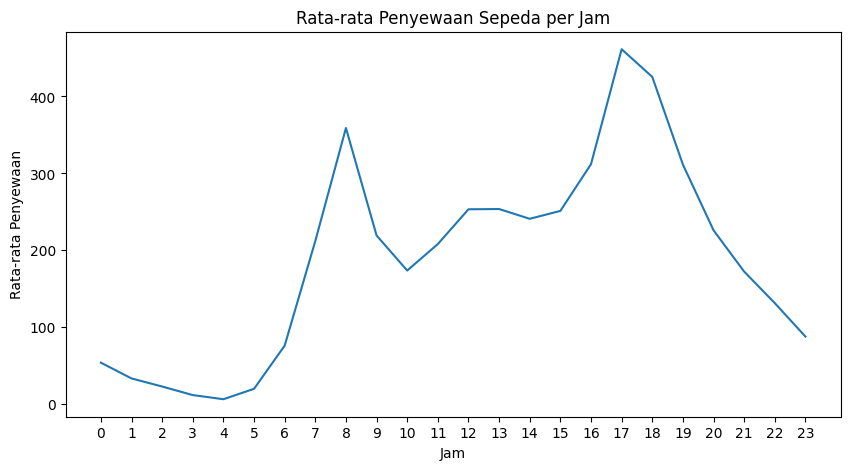

In [34]:
plt.figure(figsize=(10,5))
hour_avg.plot(kind="line")
plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.show()

Insight:

Grafik tren penyewaan per jam menunjukkan dua puncak utama dalam satu hari, yaitu pada pagi hari dan sore hari. Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi komuter, terutama untuk perjalanan menuju dan pulang dari tempat kerja atau sekolah. Sementara itu, pada dini hari hingga subuh, jumlah penyewaan relatif rendah karena aktivitas masyarakat masih terbatas.

## Conclusion

- Conclusion pertanyaan 1

Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?

Hasil analisis menunjukkan bahwa musim merupakan faktor determinan yang berpengaruh signifikan terhadap fluktuasi jumlah penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada musim Summer dan Fall, yang secara karakteristik memiliki suhu lebih hangat dan kondisi lingkungan yang relatif stabil. Sebaliknya, musim Winter menunjukkan penurunan permintaan yang cukup tajam. Pola ini mengindikasikan adanya sensitivitas permintaan terhadap faktor lingkungan eksternal, khususnya suhu dan kenyamanan beraktivitas di luar ruangan. Secara implisit, dapat diasumsikan bahwa perilaku pengguna bersifat musiman (seasonal behavior), di mana peningkatan kenyamanan fisik mendorong intensitas penggunaan layanan. Dengan demikian, variabel musim tidak hanya memengaruhi tingkat penyewaan, tetapi juga mencerminkan pola permintaan jangka menengah yang bersifat siklikal.


---




- Conclusion pertanyaan 2

Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?

Analisis lebih lanjut menunjukkan bahwa kondisi cuaca memiliki korelasi yang jelas dengan tingkat penyewaan sepeda. Cuaca cerah menghasilkan rata-rata penyewaan tertinggi, sementara kondisi seperti hujan atau salju berat menyebabkan penurunan signifikan. Hal ini menunjukkan bahwa permintaan layanan sangat elastis terhadap perubahan kondisi cuaca. Dalam konteks perilaku konsumen, pengguna cenderung meminimalkan risiko dan ketidaknyamanan saat kondisi lingkungan tidak mendukung. Oleh karena itu, cuaca dapat dipandang sebagai variabel prediktif yang kuat dalam memodelkan permintaan harian. Selain itu, dampak cuaca terhadap penyewaan bersifat langsung dan jangka pendek, berbeda dengan pengaruh musim yang lebih bersifat struktural dan siklikal.


---



*   Conclusion Tambahan (Pola Waktu – Dataset Per Jam)

Analisis pada dataset per jam menunjukkan adanya dua puncak permintaan yang konsisten, yaitu pada pagi dan sore hari. Pola ini mengindikasikan bahwa layanan penyewaan sepeda tidak hanya digunakan untuk aktivitas rekreasi, tetapi juga sebagai sarana transportasi komuter. Permintaan yang meningkat pada jam kerja menunjukkan adanya keterkaitan dengan pola mobilitas harian masyarakat. Dengan demikian, distribusi waktu penggunaan bersifat periodik dan berulang setiap hari, memperlihatkan adanya pola permintaan yang dapat diprediksi berdasarkan siklus aktivitas masyarakat.





*Secara keseluruhan, analisis menunjukkan bahwa permintaan penyewaan sepeda dipengaruhi secara signifikan oleh faktor musiman, kondisi cuaca, serta pola aktivitas harian pengguna. Musim dengan suhu yang lebih hangat dan kondisi cuaca yang cerah secara konsisten menghasilkan tingkat penyewaan yang lebih tinggi, mengindikasikan adanya sensitivitas permintaan terhadap faktor lingkungan eksternal. Selain itu, pola dua puncak permintaan pada pagi dan sore hari memperkuat indikasi bahwa sepeda tidak hanya digunakan untuk rekreasi, tetapi juga sebagai sarana transportasi komuter yang terintegrasi dengan aktivitas kerja dan sekolah.*

*Lebih lanjut, penerapan segmentasi permintaan berbasis teknik clustering sederhana memungkinkan identifikasi hari dengan kategori Low, Medium, dan High Demand secara lebih terstruktur. Pendekatan ini memberikan perspektif strategis dalam perencanaan kapasitas operasional, optimalisasi distribusi armada, serta pengelolaan sumber daya yang lebih adaptif terhadap fluktuasi permintaan.*

*Dengan demikian, hasil analisis ini tidak hanya menjawab pertanyaan bisnis yang diajukan, tetapi juga memberikan landasan analitis yang kuat untuk mendukung pengambilan keputusan berbasis data dalam pengelolaan layanan penyewaan sepeda.*

## Export Data untuk Dashboard

Setelah seluruh proses analisis dan cleaning selesai, dataset yang telah diproses disimpan dalam format CSV untuk digunakan pada dashboard Streamlit. Dataset ini telah melalui tahap pembersihan, transformasi tipe data, serta mapping kategori sehingga siap digunakan secara langsung tanpa proses tambahan.

In [35]:
# Simpan dataset bersih untuk dashboard
day_df.to_csv("main_data.csv", index=False)
hour_df.to_csv("hour_data.csv", index=False)

print("File main_data.csv dan hour_data.csv berhasil dibuat.")

File main_data.csv dan hour_data.csv berhasil dibuat.
